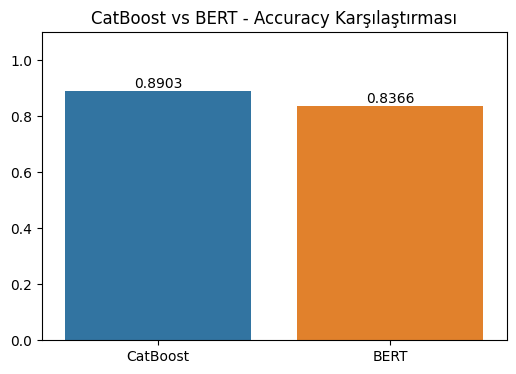

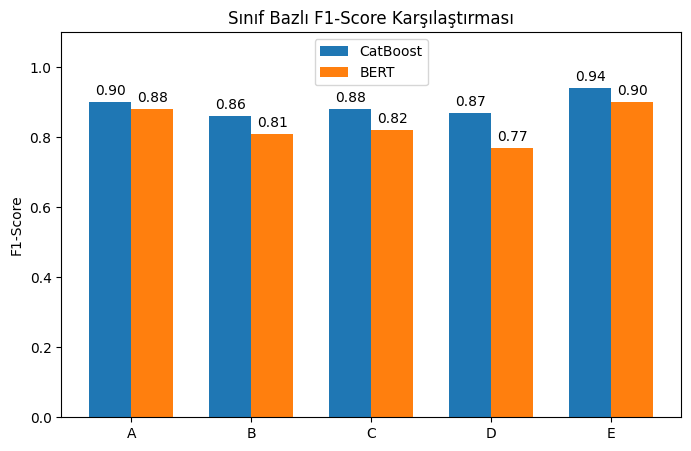

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
catboost_report = {
    'A': {'precision': 0.91, 'recall': 0.90, 'f1': 0.90},
    'B': {'precision': 0.86, 'recall': 0.87, 'f1': 0.86},
    'C': {'precision': 0.87, 'recall': 0.89, 'f1': 0.88},
    'D': {'precision': 0.90, 'recall': 0.85, 'f1': 0.87},
    'E': {'precision': 0.94, 'recall': 0.94, 'f1': 0.94},
}
catboost_accuracy = 0.8903
bert_report = {
    'A': {'precision': 0.85, 'recall': 0.91, 'f1': 0.88},
    'B': {'precision': 0.84, 'recall': 0.79, 'f1': 0.81},
    'C': {'precision': 0.81, 'recall': 0.82, 'f1': 0.82},
    'D': {'precision': 0.81, 'recall': 0.74, 'f1': 0.77},
    'E': {'precision': 0.87, 'recall': 0.93, 'f1': 0.90},
}
bert_accuracy = 0.8366
accuracies = [catboost_accuracy, bert_accuracy]
labels = ['CatBoost', 'BERT']

plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=accuracies, hue=labels, palette=['#1f77b4', '#ff7f0e'])
plt.title('CatBoost vs BERT - Accuracy Karşılaştırması')
plt.ylim(0, 1.1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.show()
classes = ['A', 'B', 'C', 'D', 'E']
cat_f1 = [catboost_report[c]['f1'] for c in classes]
bert_f1 = [bert_report[c]['f1'] for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, cat_f1, width, label='CatBoost', color='#1f77b4')
rects2 = ax.bar(x + width/2, bert_f1, width, label='BERT', color='#ff7f0e')

ax.set_ylabel('F1-Score')
ax.set_title('Sınıf Bazlı F1-Score Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.set_ylim(0, 1.1)

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


### Karşılaştırma ve Yorum

**1. Hangi model genel olarak daha iyi?**
CatBoost modeli (Accuracy: ~0.89), BERT modelinden (Accuracy: ~0.84) açıkça daha iyi bir genel doğruluk oranına sahip. Tabular veri seti üzerinde CatBoost'un başarısı daha yüksek olmuştur.

**2. Hangi sınıfta hangi model daha iyi?**
Tüm sınıfların F1-Skorlarına bakıldığında CatBoost, A, B, C, D ve E sınıflarının tamamında BERT'i geride bırakmıştır. Özellikle orta sınıflarda (B, C, D) CatBoost çok daha istikrarlı (0.86-0.88 F1) iken, BERT bu sınıfları ayırmada daha fazla zorlanmıştır (0.77-0.82 F1).

**3. Neden CatBoost Daha İyi Olabilir?**
Veri setimiz özünde **Tabular (Tablo)** bir veridir. Besin değerleri (yağ, şeker, protein vb.) sürekli sayısal değerlerdir. Biz BERT kullanabilmek için bu sayısal verileri zorla "Enerji: 250kcal, Yağ: 12g..." şeklinde serbest metne çevirdik.
BERT (ve benzeri NLP modelleri) sayıların büyüklüğünü (12g'ın 5g'dan büyük olduğunu) doğrudan matematiksel olarak değil, string/token bağlamı olarak öğrenmeye çalışır. CatBoost ise doğrudan gradient boosting kullanarak sayısal karar ağaçları oluşturur ve eşik değerlerini kusursuz yakalar. Nutri-Score hesaplaması katı kuralları olan matematiksel bir formüle dayandığı için, CatBoost bu örüntüleri ağaç yapısıyla BERT'ten çok daha kolay ve verimli bir şekilde çözmüştür.